In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import copy
import matplotlib.pyplot as plt


from ICML_comparisons import *
from ICML_MVRseq import *
# from ICML_ILP import hmm_constrained_inference
from ICML_beam_search import *

In [9]:
import gc
# Clear all cached memory
torch.cuda.empty_cache()

# Force Python garbage collection
gc.collect()

# Clear cache again after garbage collection
torch.cuda.empty_cache()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# Experiments: Generate HMM

In [4]:
# Generate random HMM
print("=== Generating Random HMM ===")
num_states = 50
num_emissions = 10
hmm_params = generate_random_hmm(num_states, num_emissions, seed=42)
transition_matrix, emission_matrix, initial_vector = hmm_params

print(f"Generated HMM with {num_states} states and {num_emissions} emissions")

hidden_states = list(range(num_states))
emit_states = list(range(num_emissions))
hidden_size, emit_size = len(hidden_states), len(emit_states)


hmm_transition = {}
for i in range(hidden_size):
    for j in range(hidden_size):
        hmm_transition[hidden_states[i],hidden_states[j]] = transition_matrix[i,j].item()

hmm_emit = {}
for i in range(hidden_size):
    for j in range(emit_size):
        hmm_emit[hidden_states[i],emit_states[j]] = emission_matrix[i,j].item()
        
hmm_startprob = {}
for i in range(hidden_size):
    hmm_startprob[hidden_states[i]] = initial_vector[i]

hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))

=== Generating Random HMM ===
Generated HMM with 50 states and 10 emissions


In [5]:
# Define constraint: encourage consecutive sequence [0,1,2,...,N-1]
constraint_length = 10
print(f"\n=== Constraint: Consecutive Sequence [0,1,2,...,{constraint_length-1}] ===")
required_transitions = [(i, i+1) for i in range(constraint_length - 1)]
print(f"Required transitions: {required_transitions}")

#Create constraint object for MVR
seq_cst = create_seqconstraint(num_states,constraint_length)
cst_list = [seq_cst]

# Sample from the HMM
print("\n=== Sampling from HMM ===")
states, observations = sample_from_hmm(
    transition_matrix, emission_matrix, initial_vector,
    sequence_length=100,
    constraint_length=constraint_length,  # Inject consecutive sequence when 0 is encountered
    seed=123
)
print(f"Sequence length: {len(observations)}")
print(f"First 20 hidden states: {states[:20].tolist()}")
print(f"First 20 observations:  {observations[:20].tolist()}")

# Verify the contiguous sequence is present
max_consecutive_in_sample = find_longest_consecutive_sequence(
    [s.item() for s in states], 
    start_state=0
)
print(f"Verified: Sample contains contiguous sequence [0, 1, ..., {max_consecutive_in_sample-1}] (length {max_consecutive_in_sample}/{constraint_length})")
if max_consecutive_in_sample >= constraint_length:
    print(f"Full constraint sequence present in sample")
else:
    print(f"WARNING: Sample only has partial sequence")

# Find the ground truth endpoint
endpoint_idx = find_constraint_endpoint(states, constraint_length)
print(f"Ground truth constraint endpoint: index {endpoint_idx} (state {states[endpoint_idx].item()})")


=== Constraint: Consecutive Sequence [0,1,2,...,9] ===
Required transitions: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9)]

=== Sampling from HMM ===
Sequence length: 100
First 20 hidden states: [37, 49, 2, 47, 33, 9, 1, 38, 24, 18, 10, 28, 0, 1, 2, 3, 4, 5, 6, 7]
First 20 observations:  [4, 0, 6, 4, 0, 3, 5, 3, 2, 6, 6, 7, 4, 6, 6, 0, 3, 4, 9, 5]
Verified: Sample contains contiguous sequence [0, 1, ..., 9] (length 10/10)
Full constraint sequence present in sample
Ground truth constraint endpoint: index 21 (state 9)


In [6]:
seq_cst = create_seqconstraint(num_states,constraint_length)
cst_list = [seq_cst]
cst_parameters = create_seq_cst_params(num_states, constraint_length, device='cpu')
input_list = Viterbi_preprocess(hmm, cst_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, hmm_params = [transition_matrix,initial_vector], cst_params = cst_parameters)
# input_list2 = Viterbi_preprocess(hmm, cst_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, hmm_params = [transition_matrix,initial_vector])
# for i in range(1,4):
#     print(torch.norm(input_list[2][i][0] - input_list2[2][i][0]))

# Testing Algorithms

In [7]:
#MV
start = time.time()
opt_state_list, opt_augstateix_list = Viterbi_torch_list(input_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)
time_elapsed = time.time() - start

print(f"Time: {time_elapsed:.4f}s")

print("Top decoded path:")
print(f"  Path: {opt_state_list[:20]}... (first 20 states)")
print(f"  Score: {hmm_log_probability(opt_state_list, observations.tolist(), initial_vector, transition_matrix, emission_matrix):.4f}")

# Check which required transitions appear in top path
print(f"\n=== Sequence Analysis ===")
top_path = torch.tensor(opt_state_list)
max_consecutive_length = find_longest_consecutive_sequence(top_path, start_state=0)
print(f"Longest consecutive sequence found: [0, 1, ..., {max_consecutive_length-1}] (length {max_consecutive_length})")
print(f"Target constraint length: {constraint_length}")
if max_consecutive_length >= constraint_length:
    print(f"MVR successfully recovered the full constraint sequence!")
else:
    print(f"MVR found partial sequence ({max_consecutive_length}/{constraint_length})")

infer_endpoint_idx = find_constraint_endpoint(top_path, constraint_length)
endpoint_idx = find_constraint_endpoint(states, constraint_length)

print(f"Inferred constraint endpoint: index {infer_endpoint_idx} (state {top_path[infer_endpoint_idx].item()})")
print(f"Ground truth constraint endpoint: index {endpoint_idx} (state {states[endpoint_idx].item()})")

Time: 0.0927s
Top decoded path:
  Path: [30, 49, 18, 12, 42, 14, 1, 48, 17, 18, 22, 35, 30, 49, 18, 3, 25, 22, 35, 1]... (first 20 states)
  Score: -409.0121

=== Sequence Analysis ===
Longest consecutive sequence found: [0, 1, ..., 9] (length 10)
Target constraint length: 10
MVR successfully recovered the full constraint sequence!
Inferred constraint endpoint: index 60 (state 9)
Ground truth constraint endpoint: index 21 (state 9)


In [10]:
# Test both version of beam search
print("\n=== Testing Implementation Match ===")

# Create original bonus function
bonus_fn_original = create_sequence_bonus_incentive(
    constraint_length=constraint_length,
    bonus_per_transition=3.0
)

# Create vectorized bonus function
bonus_matrix, bonus_fn_vectorized = create_sequence_bonus_incentive_vectorized(
    constraint_length=constraint_length,
    bonus_per_transition=3.0,
    device=device,
    num_states=transition_matrix.shape[0]
)
bonus_fn_vectorized.bonus_matrix = bonus_matrix

# Run original implementation
print("\nRunning original implementation...")
start = time.time()
paths_original, scores_original = hmm_beam_search(
    transition_matrix=transition_matrix,
    emission_matrix=emission_matrix,
    initial_vector=initial_vector,
    observations=observations,
    beam_width=5,
    bonus_fn=bonus_fn_original
)
time_original = time.time() - start
print(f"Time: {time_original:.4f}s")

# Run vectorized implementation
print("\nRunning vectorized implementation...")
start = time.time()
paths_vectorized, scores_vectorized = hmm_beam_search_vectorized(
    transition_matrix=transition_matrix,
    emission_matrix=emission_matrix,
    initial_vector=initial_vector,
    observations=observations,
    beam_width=5,
    device = device,
    bonus_fn=bonus_fn_vectorized
)
time_vectorized = time.time() - start
print(f"Time: {time_vectorized:.4f}s")
print(f"Speedup: {time_original/time_vectorized:.2f}x")

# Compare results
print("\n=== Comparison ===")
paths_match = paths_vectorized[0] == paths_original[0]
scores_close = torch.allclose(scores_vectorized[0], scores_original[0], atol=1e-4)
score_diff = abs(scores_vectorized[0].item() - scores_original[0].item())

print(f"Top paths match: {paths_match}")
print(f"Top scores close (atol=1e-4): {scores_close}")
print(f"Score difference: {score_diff:.6f}")

if paths_match and scores_close:
    print("\n✓ PASS: Implementations match!")
else:
    print("\n✗ FAIL: Implementations differ!")
    print(f"Original path (first 20): {paths_original[0][:20]}")
    print(f"Vectorized path (first 20): {paths_vectorized[0][:20]}")
    print(f"Original score: {scores_original[0].item():.6f}")
    print(f"Vectorized score: {scores_vectorized[0].item():.6f}")


=== Testing Implementation Match ===

Running original implementation...
Time: 0.1940s

Running vectorized implementation...
Time: 0.1999s
Speedup: 0.97x

=== Comparison ===
Top paths match: True
Top scores close (atol=1e-4): True
Score difference: 0.000031

✓ PASS: Implementations match!


In [11]:
# Run beam search with bonus function
print("\n=== Running Beam Search with Bonus Function ===")
bonus_fn = create_sequence_bonus_incentive(
    constraint_length=constraint_length,
    bonus_per_transition=3.0
)

# start = time.time()
# paths, scores = hmm_beam_search(
#     transition_matrix=transition_matrix,
#     emission_matrix=emission_matrix,
#     initial_vector=initial_vector,
#     observations=observations,
#     beam_width=5,
#     bonus_fn=bonus_fn
# )
# time_elapsed = time.time() - start

# print(f"Time: {time_elapsed:.4f}s")
# print("Top decoded path:")
# print(f"  Path: {paths[0][:20]}... (first 20 states)")
# print(f"  Score: {scores[0]:.4f}")

# # Check which required transitions appear in top path
# print(f"\n=== Sequence Analysis ===")
# top_path = paths[0]
# max_consecutive_length = find_longest_consecutive_sequence(top_path, start_state=0)
# print(f"Longest consecutive sequence found: [0, 1, ..., {max_consecutive_length-1}] (length {max_consecutive_length})")
# print(f"Target constraint length: {constraint_length}")
# if max_consecutive_length >= constraint_length:
#     print(f"✓ Beam search successfully recovered the full constraint sequence!")
# else:
#     print(f"✗ Beam search found partial sequence ({max_consecutive_length}/{constraint_length})")

# print(f"\nTrue hidden states (first 20): {states[:20].tolist()}")


# Run beam search with vectorized bonus function
print("\n=== Running Beam Search with Vectorized Bonus Function ===")

# # Create vectorized bonus function with correct num_states
# device = transition_matrix.device
# N = transition_matrix.shape[0]  # Get number of states

bonus_matrix, bonus_fn = create_sequence_bonus_incentive_vectorized(
    constraint_length=constraint_length,
    bonus_per_transition=3.0,
    device=device,
    num_states=transition_matrix.shape[0]  # Pass the number of states
)

# Attach the bonus matrix to the function for vectorized access
bonus_fn.bonus_matrix = bonus_matrix

start = time.time()
paths, scores = hmm_beam_search_vectorized(
    transition_matrix=transition_matrix,
    emission_matrix=emission_matrix,
    initial_vector=initial_vector,
    observations=observations,
    beam_width=5,
    device = device,
    bonus_fn=bonus_fn
)
time_elapsed = time.time() - start
print(f"Time: {time_elapsed:.4f}s")
print("Top decoded path:")
print(f"  Path: {paths[0][:20]}... (first 20 states)")
print(f"  Score: {scores[0]:.4f}")


# Check which required transitions appear in top path
print(f"\n=== Sequence Analysis ===")
top_path = paths[0]
max_consecutive_length = find_longest_consecutive_sequence(top_path, start_state=0)
print(f"Longest consecutive sequence found: [0, 1, ..., {max_consecutive_length-1}] (length {max_consecutive_length})")
print(f"Target constraint length: {constraint_length}")
if max_consecutive_length >= constraint_length:
    print(f"✓ Beam search successfully recovered the full constraint sequence!")
else:
    print(f"✗ Beam search found partial sequence ({max_consecutive_length}/{constraint_length})")

print(f"\nTrue hidden states (first 20): {states[:20].tolist()}")



=== Running Beam Search with Bonus Function ===

=== Running Beam Search with Vectorized Bonus Function ===
Time: 0.0246s
Top decoded path:
  Path: [18, 12, 42, 18, 12, 42, 14, 1, 48, 17, 18, 2, 28, 0, 1, 2, 3, 25, 4, 5]... (first 20 states)
  Score: -368.1712

=== Sequence Analysis ===
Longest consecutive sequence found: [0, 1, ..., 4] (length 5)
Target constraint length: 10
✗ Beam search found partial sequence (5/10)

True hidden states (first 20): [37, 49, 2, 47, 33, 9, 1, 38, 24, 18, 10, 28, 0, 1, 2, 3, 4, 5, 6, 7]


In [13]:
# # Example usage - can be run directly in Jupyter
# # Simple example: 5 states, 2 observation symbols, sequence length 15
# K = 10  # number of states
# M = 5  # number of observation symbols
# T = 10  # sequence length
# N = 4  # require subsequence [0, 1, 2, 3] to occur

# # Create random HMM parameters (in log space)
# torch.manual_seed(31)
# transition = torch.randn(K, K)
# emission = torch.randn(K, M)
# initial = torch.randn(K)

# # Random observations
# observations = torch.randint(0, M, (T,))

# print("Observations:", observations.tolist())
# print(f"Required subsequence: [0, 1, ..., {N-1}]")

# # Run constrained inference
# states, solve_time = hmm_constrained_inference(
#     observations, transition, emission, initial, N
# )

# print("Inferred states:", states.tolist())
# print(f"ILP solve time: {solve_time:.4f} seconds")

# # Verify constraint is satisfied
# def check_subsequence(states, N):
#     """Check if subsequence [0, 1, ..., N-1] occurs in states."""
#     for t in range(len(states) - N + 1):
#         if all(states[t + i] == i for i in range(N)):
#             return True, t
#     return False, None

# found, start_pos = check_subsequence(states, N)
# if found:
#     print(f"✓ Subsequence [0, 1, ..., {N-1}] found starting at position {start_pos}")
# else:
#     print(f"✗ Subsequence [0, 1, ..., {N-1}] NOT found")

# Beam vs MVR

## Runtime vs Space

In [51]:
sizes = [100*i + 50 for i in range(10)]
batch = 25
constraint_length = 10
device = torch.device("cuda:0")

required_transitions = [(i, i+1) for i in range(constraint_length - 1)]


In [52]:
# Generate random HMM
size_exp_beam = []
size_exp_beam_vec = []
size_exp_mv = []

for size in sizes:
    
    #Generate HMM
    num_states = size
    num_emissions = 10
    hmm_params = generate_random_hmm(num_states, num_emissions, seed=42)
    transition_matrix, emission_matrix, initial_vector = hmm_params


    hidden_states = list(range(num_states))
    emit_states = list(range(num_emissions))
    hidden_size, emit_size = len(hidden_states), len(emit_states)


    hmm_transition = {}
    for i in range(hidden_size):
        for j in range(hidden_size):
            hmm_transition[hidden_states[i],hidden_states[j]] = transition_matrix[i,j].item()

    hmm_emit = {}
    for i in range(hidden_size):
        for j in range(emit_size):
            hmm_emit[hidden_states[i],emit_states[j]] = emission_matrix[i,j].item()

    hmm_startprob = {}
    for i in range(hidden_size):
        hmm_startprob[hidden_states[i]] = initial_vector[i]

    hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))
    
    #Intialize bonus function for each size
    bonus_fn = create_sequence_bonus_incentive(
        constraint_length=constraint_length,
        bonus_per_transition=3.0
    )
    
    #Initialize bonus matrix 
    bonus_matrix, bonus_fn_vec = create_sequence_bonus_incentive_vectorized(
        constraint_length=constraint_length,
        bonus_per_transition=3.0,
        device=device,
        num_states=transition_matrix.shape[0]
    )
    # Attach the bonus matrix to the function for vectorized access
    bonus_fn_vec.bonus_matrix = bonus_matrix
    
    #Create constraint object for MVR
    seq_cst = create_seqconstraint(num_states,constraint_length)
    cst_list = [seq_cst]
    cst_parameters = create_seq_cst_params(num_states, constraint_length, device='cpu')

    #Initialize list of times
    times_beam = []
    times_mv = []
    times_beam_vec = []
    #Runtime experiments
    for b in range(batch):
        if b % 10 == 0:
            print(f'On size {size} and run {b}')
 
        states, observations = sample_from_hmm(
            transition_matrix, emission_matrix, initial_vector,
            sequence_length=100,
            constraint_length=constraint_length  # Inject consecutive sequence when 0 is encountered
        )

        #Beam Search
        start = time.time()
        paths, scores = hmm_beam_search(
            transition_matrix=transition_matrix,
            emission_matrix=emission_matrix,
            initial_vector=initial_vector,
            observations=observations,
            beam_width=5,
            bonus_fn=bonus_fn
        )
        time_elapsed = time.time() - start
        times_beam.append(time_elapsed)
        
        #MV
        input_list = Viterbi_preprocess(hmm, cst_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, hmm_params = [transition_matrix,initial_vector], cst_params = cst_parameters)
        start = time.time()
        opt_state_list, opt_augstateix_list = Viterbi_torch_list(input_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)
        time_elapsed = time.time() - start
        times_mv.append(time_elapsed)
        
        #Vectorized Beam Search
        start = time.time()
        paths, scores = hmm_beam_search_vectorized(
            transition_matrix=transition_matrix,
            emission_matrix=emission_matrix,
            initial_vector=initial_vector,
            observations=observations,
            beam_width=5,
            device = device,
            bonus_fn=bonus_fn_vec
        )
        time_elapsed = time.time() - start
        times_beam_vec.append(time_elapsed)
        
    
    size_exp_beam.append(times_beam)
    size_exp_mv.append(times_mv)
    size_exp_beam_vec.append(times_beam_vec)


On size 50 and run 0
On size 50 and run 10
On size 50 and run 20
On size 150 and run 0
On size 150 and run 10
On size 150 and run 20
On size 250 and run 0
On size 250 and run 10
On size 250 and run 20
On size 350 and run 0
On size 350 and run 10
On size 350 and run 20
On size 450 and run 0
On size 450 and run 10
On size 450 and run 20
On size 550 and run 0
On size 550 and run 10
On size 550 and run 20
On size 650 and run 0
On size 650 and run 10
On size 650 and run 20
On size 750 and run 0
On size 750 and run 10
On size 750 and run 20
On size 850 and run 0
On size 850 and run 10
On size 850 and run 20
On size 950 and run 0
On size 950 and run 10
On size 950 and run 20


In [53]:
import pickle

# with open('size_exp_beam.pkl', 'wb') as f:
#     pickle.dump([size_exp_mv, size_exp_beam, size_exp_beam_vec], f)


# # Loading from pickle file
# with open('size_exp_beam.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)


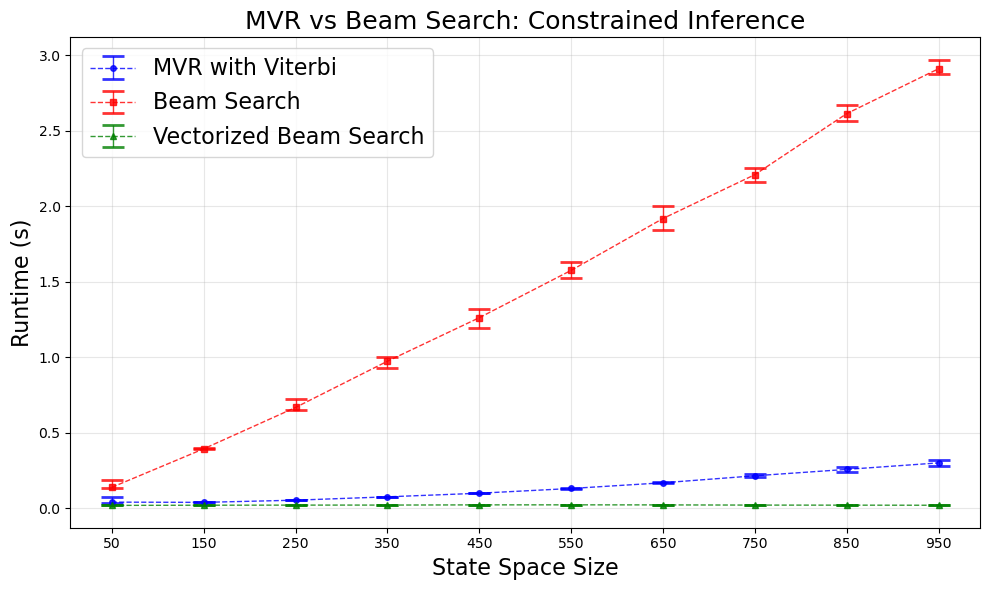

In [60]:
# Compute statistics for Algorithm 1
means_1 = [np.mean(runs) for runs in size_exp_mv]
lower_1 = [np.percentile(runs, 2.5) for runs in size_exp_mv]
upper_1 = [np.percentile(runs, 97.5) for runs in size_exp_mv]

# Compute statistics for Algorithm 2
means_2 = [np.mean(runs) for runs in size_exp_beam]
lower_2 = [np.percentile(runs, 2.5) for runs in size_exp_beam]
upper_2 = [np.percentile(runs, 97.5) for runs in size_exp_beam]

# Compute statistics for Algorithm 3
means_3 = [np.mean(runs) for runs in size_exp_beam_vec]
lower_3 = [np.percentile(runs, 2.5) for runs in size_exp_beam_vec]
upper_3 = [np.percentile(runs, 97.5) for runs in size_exp_beam_vec]

# Convert to error bar format (distance from mean)
yerr_lower_1 = np.array(means_1) - np.array(lower_1)
yerr_upper_1 = np.array(upper_1) - np.array(means_1)
yerr_lower_2 = np.array(means_2) - np.array(lower_2)
yerr_upper_2 = np.array(upper_2) - np.array(means_2)
yerr_lower_3 = np.array(means_3) - np.array(lower_3)
yerr_upper_3 = np.array(upper_3) - np.array(means_3)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Algorithm 1 with error bars
ax.errorbar(sizes, means_1, yerr=[yerr_lower_1, yerr_upper_1],
            fmt='o--', color='blue', label='MVR with Viterbi',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 2 with error bars
ax.errorbar(sizes, means_2, yerr=[yerr_lower_2, yerr_upper_2],
            fmt='s--', color='red', label='Beam Search',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 3 with error bars
ax.errorbar(sizes, means_3, yerr=[yerr_lower_3, yerr_upper_3],
            fmt='^--', color='green', label='Vectorized Beam Search',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

ax.set_xlabel('State Space Size', fontsize=16)
ax.set_ylabel('Runtime (s)', fontsize=16)
ax.set_xticks(sizes)
ax.set_title('MVR vs Beam Search: Constrained Inference', fontsize=18)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)

plt.savefig('comparison_beamTttl_time.pdf', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

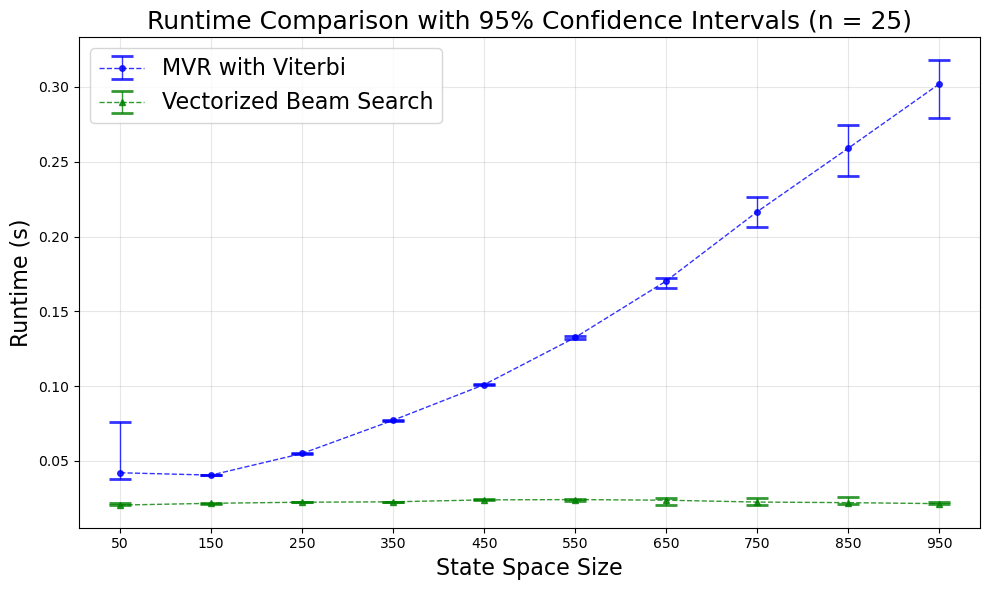

In [55]:
import matplotlib.pyplot as plt
import numpy as np


# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Algorithm 1 with error bars
ax.errorbar(sizes, means_1, yerr=[yerr_lower_1, yerr_upper_1],
            fmt='o--', color='blue', label='MVR with Viterbi',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 3 with error bars
ax.errorbar(sizes, means_3, yerr=[yerr_lower_3, yerr_upper_3],
            fmt='^--', color='green', label='Vectorized Beam Search',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

ax.set_xlabel('State Space Size', fontsize=16)
ax.set_ylabel('Runtime (s)', fontsize=16)
ax.set_xticks(sizes)
ax.set_title('Runtime Comparison with 95% Confidence Intervals (n = 25)', fontsize=18)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)

plt.savefig('comparison_beamVec_time.pdf', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

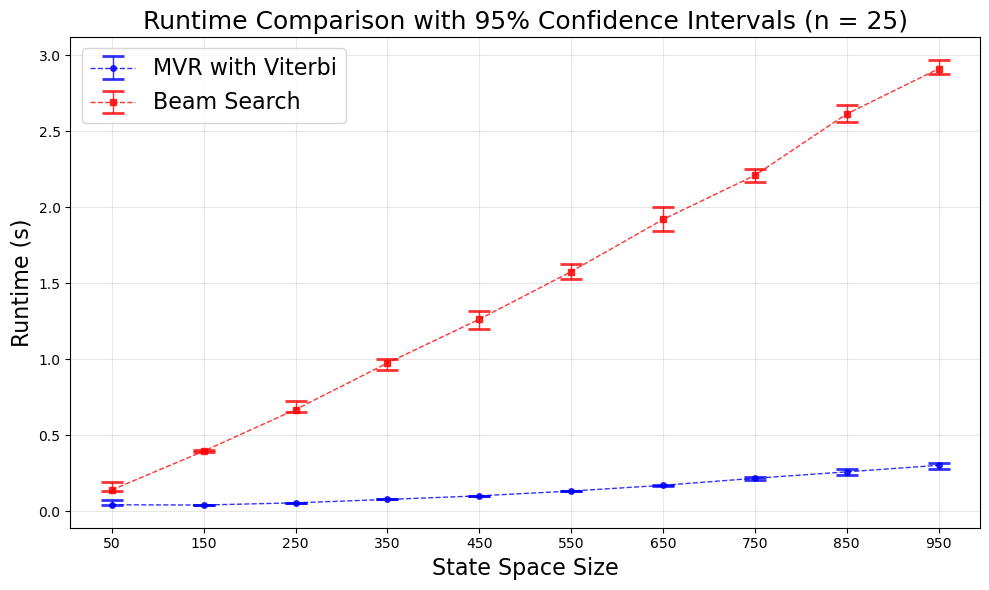

In [56]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Algorithm 1 with error bars
ax.errorbar(sizes, means_1, yerr=[yerr_lower_1, yerr_upper_1],
            fmt='o--', color='blue', label='MVR with Viterbi',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 2 with error bars
ax.errorbar(sizes, means_2, yerr=[yerr_lower_2, yerr_upper_2],
            fmt='s--', color='red', label='Beam Search',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

ax.set_xlabel('State Space Size', fontsize=16)
ax.set_ylabel('Runtime (s)', fontsize=16)
ax.set_xticks(sizes)
ax.set_title('Runtime Comparison with 95% Confidence Intervals (n = 25)', fontsize=18)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)

plt.savefig('comparison_beam_time.pdf', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## Constraint Length vs Max Inferred Subsequence

In [57]:
constraint_lengths = [2*i for i in range(1,10)]
batch = 100
size = 50
device = torch.device("cuda:0")


#Generate HMM
num_states = size
num_emissions = 10
hmm_params = generate_random_hmm(num_states, num_emissions, seed=42)
transition_matrix, emission_matrix, initial_vector = hmm_params


hidden_states = list(range(num_states))
emit_states = list(range(num_emissions))
hidden_size, emit_size = len(hidden_states), len(emit_states)


hmm_transition = {}
for i in range(hidden_size):
    for j in range(hidden_size):
        hmm_transition[hidden_states[i],hidden_states[j]] = transition_matrix[i,j].item()

hmm_emit = {}
for i in range(hidden_size):
    for j in range(emit_size):
        hmm_emit[hidden_states[i],emit_states[j]] = emission_matrix[i,j].item()

hmm_startprob = {}
for i in range(hidden_size):
    hmm_startprob[hidden_states[i]] = initial_vector[i]

hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))


In [58]:
# Generate random HMM
accuracy_exp_beam = []
accuracy_exp_mv = []

for length in constraint_lengths:
    
    required_transitions = [(i, i+1) for i in range(length - 1)]

    states, observations = sample_from_hmm(
        transition_matrix, emission_matrix, initial_vector,
        sequence_length=100,
        constraint_length=length,  # Inject consecutive sequence when 0 is encountered
        seed=123
    )
    #Intialize bonus function for each size
    bonus_fn = create_sequence_bonus_incentive(
        constraint_length=length,
        bonus_per_transition=3.0
    )
    
    #Initialize bonus matrix 
    bonus_matrix, bonus_fn_vec = create_sequence_bonus_incentive_vectorized(
        constraint_length=length,
        bonus_per_transition=3.0,
        device=device,
        num_states=transition_matrix.shape[0]
    )
    # Attach the bonus matrix to the function for vectorized access
    bonus_fn_vec.bonus_matrix = bonus_matrix
    
    #Create constraint object for MVR
    seq_cst = create_seqconstraint(num_states,length)
    cst_list = [seq_cst]
    cst_parameters = create_seq_cst_params(num_states, length, device='cpu')

    #Initialize list of times
    accuracy_beam = []
    accuracy_mv = []
    #Runtime experiments
    for b in range(batch):
        if b % 10 == 0:
            print(f'On constraint length {length} and run {b}')
 
        states, observations = sample_from_hmm(
            transition_matrix, emission_matrix, initial_vector,
            sequence_length=100,
            constraint_length=length # Inject consecutive sequence when 0 is encountered
        )

        #Beam Search
        paths, scores = hmm_beam_search(
            transition_matrix=transition_matrix,
            emission_matrix=emission_matrix,
            initial_vector=initial_vector,
            observations=observations,
            beam_width=5,
            bonus_fn=bonus_fn
        )
        top_path = paths[0]
        max_consecutive_length = find_longest_consecutive_sequence(top_path, start_state=0, constraint_length = length)
        accuracy_beam.append(max_consecutive_length/length)
        
        #MV
        input_list = Viterbi_preprocess(hmm, cst_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, hmm_params = [transition_matrix,initial_vector], cst_params = cst_parameters)
        opt_state_list, opt_augstateix_list = Viterbi_torch_list(input_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)
        top_path = torch.tensor(opt_state_list)
        max_consecutive_length = find_longest_consecutive_sequence(top_path, start_state=0, constraint_length = length)
        accuracy_mv.append(max_consecutive_length/length)
    
    accuracy_exp_beam.append(accuracy_beam)
    accuracy_exp_mv.append(accuracy_mv)


On constraint length 2 and run 0
On constraint length 2 and run 10
On constraint length 2 and run 20
On constraint length 2 and run 30
On constraint length 2 and run 40
On constraint length 2 and run 50
On constraint length 2 and run 60
On constraint length 2 and run 70
On constraint length 2 and run 80
On constraint length 2 and run 90
On constraint length 4 and run 0
On constraint length 4 and run 10
On constraint length 4 and run 20
On constraint length 4 and run 30
On constraint length 4 and run 40
On constraint length 4 and run 50
On constraint length 4 and run 60
On constraint length 4 and run 70
On constraint length 4 and run 80
On constraint length 4 and run 90
On constraint length 6 and run 0
On constraint length 6 and run 10
On constraint length 6 and run 20
On constraint length 6 and run 30
On constraint length 6 and run 40
On constraint length 6 and run 50
On constraint length 6 and run 60
On constraint length 6 and run 70
On constraint length 6 and run 80
On constraint len

In [19]:
import pickle

with open('acc_exp_beam.pkl', 'wb') as f:
    pickle.dump([accuracy_exp_mv, accuracy_exp_beam], f)


# # Loading from pickle file
# with open('acc_exp_beam.pkl', 'rb') as f:
#     loaded_data = pickle.load(f)


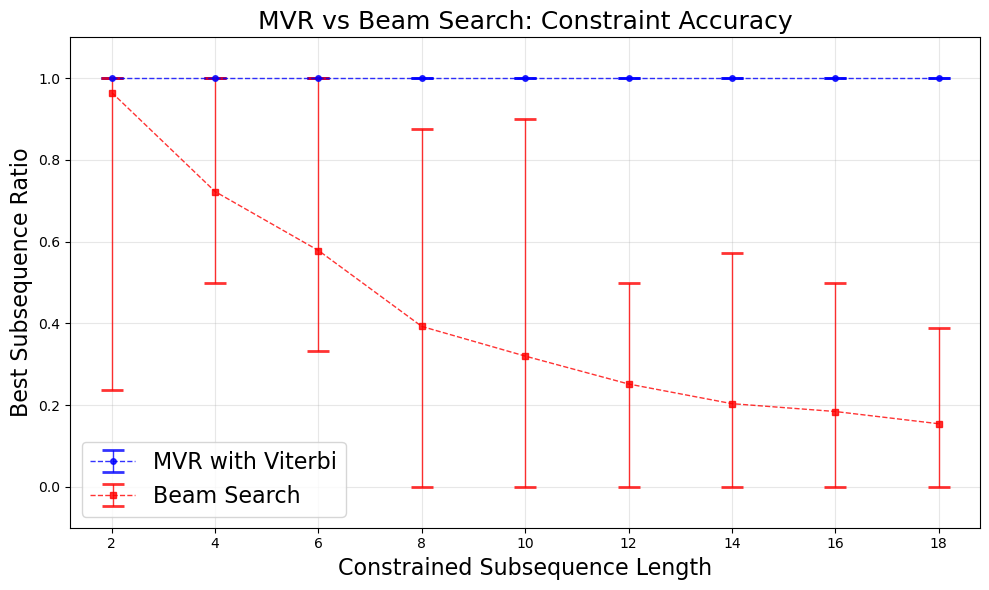

In [64]:
# Compute statistics for Algorithm 1
acc_means_1 = [np.mean(runs) for runs in accuracy_exp_mv]
acc_lower_1 = [np.percentile(runs, 2.5) for runs in accuracy_exp_mv]
acc_upper_1 = [np.percentile(runs, 97.5) for runs in accuracy_exp_mv]

# Compute statistics for Algorithm 2
acc_means_2 = [np.mean(runs) for runs in accuracy_exp_beam]
acc_lower_2 = [np.percentile(runs, 2.5) for runs in accuracy_exp_beam]
acc_upper_2 = [np.percentile(runs, 97.5) for runs in accuracy_exp_beam]


# Convert to error bar format (distance from mean)
acc_yerr_lower_1 = np.array(acc_means_1) - np.array(acc_lower_1)
acc_yerr_upper_1 = np.array(acc_upper_1) - np.array(acc_means_1)
acc_yerr_lower_2 = np.array(acc_means_2) - np.array(acc_lower_2)
acc_yerr_upper_2 = np.array(acc_upper_2) - np.array(acc_means_2)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Algorithm 1 with error bars
ax.errorbar(constraint_lengths, acc_means_1, yerr=[acc_yerr_lower_1.round(4), acc_yerr_upper_1.round(4)],
            fmt='o--', color='blue', label='MVR with Viterbi',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 2 with error bars
ax.errorbar(constraint_lengths, acc_means_2, yerr=[acc_yerr_lower_2.round(4), acc_yerr_upper_2.round(4)], #handle small negative values due to imprecision
            fmt='s--', color='red', label='Beam Search',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

ax.set_xlabel('Constrained Subsequence Length', fontsize=16)
ax.set_ylabel('Best Subsequence Ratio', fontsize=16)
ax.set_xticks(constraint_lengths)
ax.set_title('MVR vs Beam Search: Constraint Accuracy', fontsize=18)
ax.legend(fontsize=16)
ax.set_ylim([-.1,1.1])
ax.grid(alpha=0.3)

plt.savefig('comparison_beam_accuracy.pdf', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# ILP vs MV

## Runtime: Sequence Length

In [26]:
batch = 25
num_states = 20
num_emissions = 10
constraint_length = 10
seq_lengths = [50*i for i in range(1,7)]

device = torch.device("cuda:0")

required_transitions = [(i, i+1) for i in range(constraint_length - 1)]

#Generate HMM
hmm_params = generate_random_hmm(num_states, num_emissions, seed=42)
transition_matrix, emission_matrix, initial_vector = hmm_params


hidden_states = list(range(num_states))
emit_states = list(range(num_emissions))
hidden_size, emit_size = len(hidden_states), len(emit_states)


hmm_transition = {}
for i in range(hidden_size):
    for j in range(hidden_size):
        hmm_transition[hidden_states[i],hidden_states[j]] = transition_matrix[i,j].item()

hmm_emit = {}
for i in range(hidden_size):
    for j in range(emit_size):
        hmm_emit[hidden_states[i],emit_states[j]] = emission_matrix[i,j].item()

hmm_startprob = {}
for i in range(hidden_size):
    hmm_startprob[hidden_states[i]] = initial_vector[i]

hmm = copy.deepcopy(Munch(states = hidden_states, emits = emit_states, tprob = hmm_transition, eprob = hmm_emit, initprob = hmm_startprob))


#Create constraint object for MVR
seq_cst = create_seqconstraint(num_states,constraint_length)
cst_list = [seq_cst]
cst_parameters = create_seq_cst_params(num_states, constraint_length, device='cpu')


In [27]:
# Generate random HMM
length_exp_mv = []
fail_list = []
# length_exp_ilp = []

for length in seq_lengths:
    fail_ctr = 0
    #Initialize list of times
    # times_ilp = []
    times_mv = []
    #Runtime experiments
    for b in range(batch):
        if b % 10 == 0:
            print(f'On length {length} and run {b}')
 
        states, observations = sample_from_hmm(
            transition_matrix, emission_matrix, initial_vector,
            sequence_length=length,
            constraint_length=constraint_length  # Inject consecutive sequence when 0 is encountered
        )

        
        #MV
        input_list = Viterbi_preprocess(hmm, cst_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, hmm_params = [transition_matrix,initial_vector], cst_params = cst_parameters)
        start = time.time()
        opt_state_list, opt_augstateix_list = Viterbi_torch_list(input_list, observations.tolist(), dtype = torch.float32,  device = 'cuda:0', debug = False, num_corr = 0)
        time_elapsed = time.time() - start
        times_mv.append(time_elapsed)
        
        # #ILP
        # states, solve_time = hmm_constrained_inference(
        #     observations, transition_matrix, emission_matrix, initial_vector, constraint_length
        # )
        # times_ilp.append(solve_time)
        
        # Check that solution is feasible
        failed_length = False
        max_length = find_longest_consecutive_sequence(opt_state_list)
        failed_length = max_length < constraint_length
        if failed_length: #increment by 1 if failure at any point
            fail_ctr += 1
            print(f'Infeasible solution on experiment setting {length} and batch {b}')
    # length_exp_ilp.append(times_ilp)
    length_exp_mv.append(times_mv)
    fail_list.append(fail_ctr)


On length 50 and run 0
On length 50 and run 10
On length 50 and run 20
On length 100 and run 0
On length 100 and run 10
On length 100 and run 20
On length 150 and run 0
On length 150 and run 10
On length 150 and run 20
On length 200 and run 0
On length 200 and run 10
On length 200 and run 20
On length 250 and run 0
On length 250 and run 10
On length 250 and run 20
On length 300 and run 0
On length 300 and run 10
On length 300 and run 20


In [29]:
data_mvr = {'seq_lengths': seq_lengths, 
        'batch_size': batch,
        'constraint_length': constraint_length,
       'hmm_details': [num_states, num_emissions ],
       'runtimes': length_exp_mv,
       'num_fails': fail_list}

with open("data_mvr.json", "w") as f:
    json.dump(data_mvr, f, indent=2)


# with open("data_mvr.json", "r") as f:
#     data_mvr = json.load(f)


In [18]:
with open("data_ilp.json", "r") as f:
    data_ilp = json.load(f)


In [24]:
data_ilp.keys()

dict_keys(['seq_lengths', 'batch_size', 'constraint_length', 'hmm_details', 'runtimes', 'num_fails'])

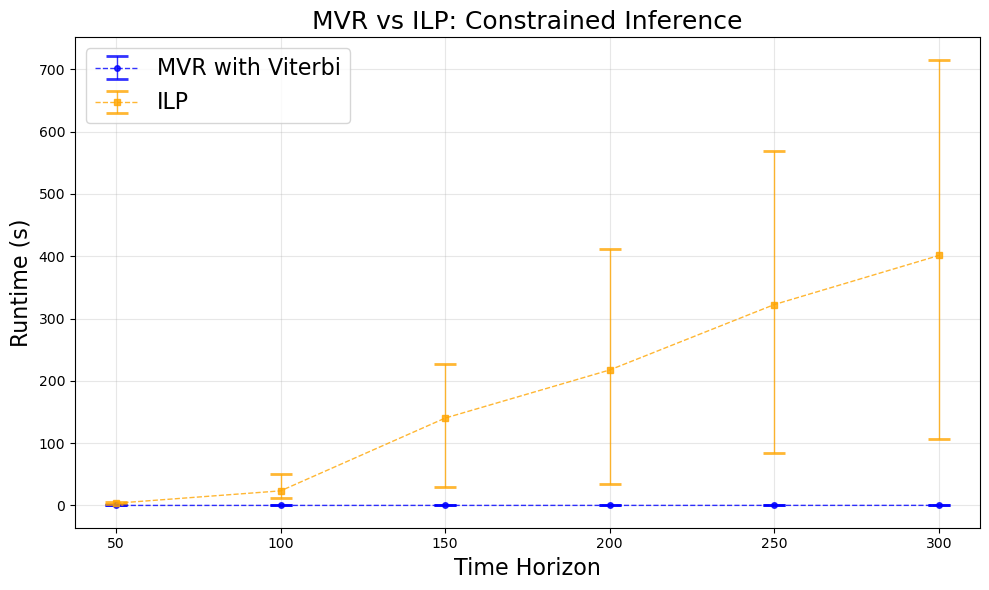

In [65]:
# Compute statistics for Algorithm 1
length_exp_mv = data_mvr['runtimes']
length_exp_ilp = data_ilp['runtimes']

# #Convert to log scale
# length_exp_mv = [[np.log10(time) for time in run] for run in length_exp_mv]
# length_exp_ilp = [[np.log10(time) for time in run] for run in length_exp_ilp]


means_1 = [np.mean(runs) for runs in length_exp_mv]
lower_1 = [np.percentile(runs, 2.5) for runs in length_exp_mv]
upper_1 = [np.percentile(runs, 97.5) for runs in length_exp_mv]

# Compute statistics for Algorithm 2
means_2 = [np.mean(runs) for runs in length_exp_ilp]
lower_2 = [np.percentile(runs, 2.5) for runs in length_exp_ilp]
upper_2 = [np.percentile(runs, 97.5) for runs in length_exp_ilp]


# Convert to error bar format (distance from mean)
yerr_lower_1 = np.array(means_1) - np.array(lower_1)
yerr_upper_1 = np.array(upper_1) - np.array(means_1)
yerr_lower_2 = np.array(means_2) - np.array(lower_2)
yerr_upper_2 = np.array(upper_2) - np.array(means_2)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Algorithm 1 with error bars
ax.errorbar(seq_lengths, means_1, yerr=[yerr_lower_1.round(4), yerr_upper_1.round(4)],
            fmt='o--', color='blue', label='MVR with Viterbi',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

# Plot Algorithm 2 with error bars
ax.errorbar(seq_lengths, means_2, yerr=[yerr_lower_2.round(4), yerr_upper_2.round(4)], #handle small negative values due to imprecision
            fmt='s--', color='orange', label='ILP',
            capsize=8, capthick=2, linewidth=1, markersize=4, alpha=0.8)

ax.set_xlabel('Time Horizon', fontsize=16)
# ax.set_ylabel('$\log_{10}$(Runtime(s))', fontsize=16)
# plt.yscale('log')
plt.ylabel('Runtime (s)', fontsize= 16)
ax.set_xticks(seq_lengths)
ax.set_title('MVR vs ILP: Constrained Inference', fontsize=18)
ax.legend(fontsize=16)
# ax.set_ylim([-.1,1.1])
ax.grid(alpha=0.3)

plt.savefig('comparison_ilp_time.pdf', format='png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()